# Exercise 1

## Import packages

In [2]:
import skimage.io
import skimage.color
import skimage.exposure
import numpy as np
import matplotlib.pyplot as plt

## Task 1

Implementation of some basic vector and matrix calculations using NumPy.

Reference: https://numpy.org/doc/1.18/reference/index.html

Create the following vectors and matrix using numpy. They should use floating point as data type.
$$
a = \begin{bmatrix}
1 & 0 & 1 & 0 & 1
\end{bmatrix}
$$

$$
b = \begin{bmatrix}
1 & 2 & 3 & 4 & 5
\end{bmatrix}
$$

$$
M =\begin{bmatrix}
1 & 2 & 3\\
4 & 5 & 6\\
7 & 8 & 9\\
\end{bmatrix}
$$

Also define the following scalar value
$$k = 5.0$$

In [3]:
# TODO: Create vectors, matrix and scalar value
a = np.array([1, 0, 1, 0, 1], dtype=np.float32)
b = np.array([1, 2, 3, 4, 5], dtype=np.float32)
M = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.float32)
k = 5.0

print(f'a = {a}')
print(f'b = {b}')
print(f'M = {M}')
print(f'k = {k}')

a = [1. 0. 1. 0. 1.]
b = [1. 2. 3. 4. 5.]
M = [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
k = 5.0


In [4]:
# TODO: Add vector a with vector b
add = a + b
np.testing.assert_allclose(add, np.array([2, 2, 4, 4, 6]))
print(f'a + b = {add}')

# TODO: Multiply vector a with scalar value k
mult = a * k
np.testing.assert_allclose(mult, np.array([5, 0, 5, 0, 5]))
print(f'k * a = {mult}')

# TODO: Dot product between a and b
dot = np.dot(a, b)
np.testing.assert_allclose(dot, 9.0)
print(f'<a, b> = {dot}')

# TODO: Create vector c by slicing vector a in order to get [0, 1, 0]
c = a[1:4]
np.testing.assert_allclose(c, [0, 1, 0])
print(f'c = {c}')

# TODO: Multiply vector c with matrix M
cM_mult = c * M
np.testing.assert_allclose(cM_mult, [[0, 2, 0], [0, 5, 0], [0, 8, 0]])
print(f'c * M = {cM_mult}')

# TODO: Dot product between vector c and matrix M
cM_dot = np.dot(c, M)
np.testing.assert_allclose(cM_dot, [4, 5, 6])
print(f'<c, M> = {cM_dot}')

# TODO: Use a numpy-helper function to create a vector d = [0, 1, 2 ..., 99]
d = np.arange(100)

# TODO: Now use slicing with strides to reduce this vector to d_small = [40, 50, 60]
d_small = d[40:61:10]
np.testing.assert_allclose(d_small, [40, 50, 60])

print(f'd_small = {d_small}')

a + b = [2. 2. 4. 4. 6.]
k * a = [5. 0. 5. 0. 5.]
<a, b> = 9.0
c = [0. 1. 0.]
c * M = [[0. 2. 0.]
 [0. 5. 0.]
 [0. 8. 0.]]
<c, M> = [4. 5. 6.]
d_small = [40 50 60]


## Task 2

1. Load the image in ```./data/pepo.jpg``` from your disk and store it in a variable named ```image``` (use ```skimage.io```).
2. Store and print the shape of the image and the value range (min and max values).
3. Convert it to gray scale and save it in a variable named ```image_gray``` (use ```skimage.color```).
4. Store and print the shape of the grayscale image and the value range (min and max values).
5. Save the grayscale image back to disk in ```./data/pepo_gray.jpg``` (use ```skimage.io```).
6. Use Matplotlib to show the RGB and the grayscale image side by side.

Reference: https://scikit-image.org/docs/stable/index.html  
Reference: https://matplotlib.org/users/index.html  

In [5]:
# TODO: 1. Load the image in ./data/pepo.jpg from your disk and store it in a variable named image
image = skimage.io.imread("./data/pepo.jpg")

# TODO: 2. Store and print the shape of the image and the value range (min and max values)
rgb_image_shape = image.shape
rgb_min = image.min()
rgb_max = image.max()
print(f'RGB image shape: {rgb_image_shape}')
print(f'RGB image min: {rgb_min}')
print(f'RGB image max: {rgb_max}')

# TODO: 3. Convert it to gray scale and save it in a variable named image_gray
image_gray = skimage.color.rgb2gray(image)

# TODO: 4. Store and print the shape of the grayscale image and the value range (min and max values)
grayscale_image_shape = image_gray.shape
grayscale_min = image_gray.min()
grayscale_max = image_gray.max()

print(f'Grayscale image shape: {grayscale_image_shape}')
print(f'Grayscale image min: {grayscale_min}')
print(f'Grayscale image max: {grayscale_max}')

# TODO: 5. Save the grayscale image back to disk in ./data/pepo_gray.jpg
from skimage import img_as_ubyte 
image_gray_uint8 = img_as_ubyte(image_gray) # Preventing lossy conversion from float64 to uint8 because jpg saves int not float
skimage.io.imsave("./data/pepo_gray.jpg", image_gray_uint8)

RGB image shape: (512, 512, 3)
RGB image min: 0
RGB image max: 255
Grayscale image shape: (512, 512)
Grayscale image min: 0.0008333333333333333
Grayscale image max: 1.0


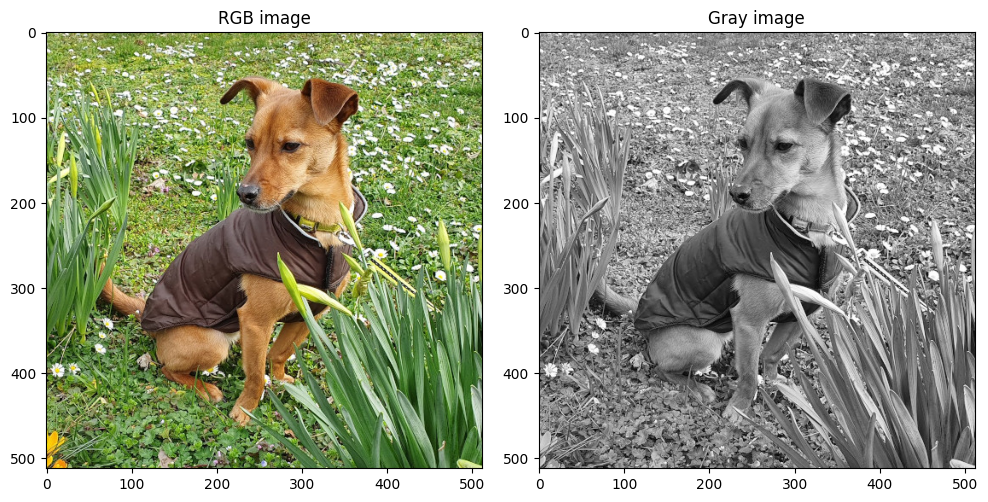

In [5]:
# TODO: 6. Use Matplotlib to show the RGB and the grayscale image side by side.
# Make sure that the gray image is displayed in gray.
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

# for the RGB image
axs[0].imshow(image)
axs[0].set_title("RGB image")

# for the gray image
axs[1].imshow(image_gray, cmap="gray")
axs[1].set_title("Gray image")

plt.tight_layout()
plt.show()

## Task 3

Plot the color histogram of the rgb image.

Reference: https://matplotlib.org/users/index.html

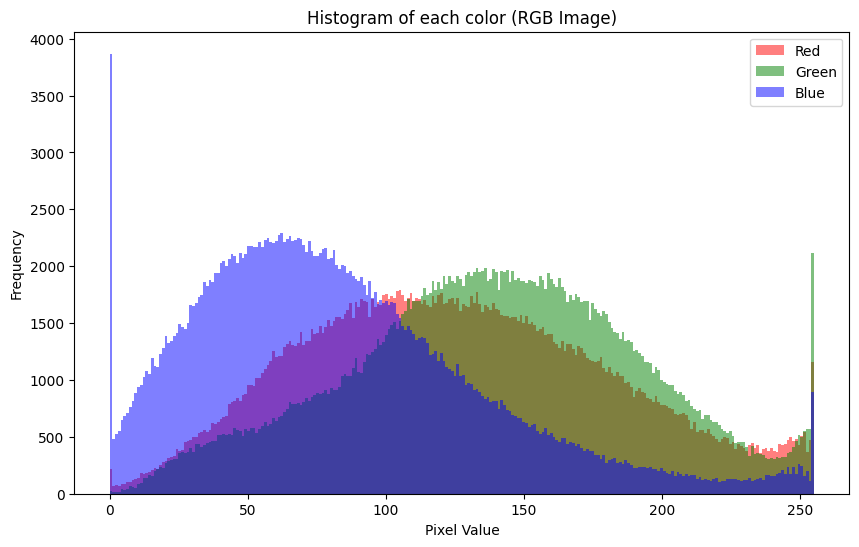

In [6]:
def plot_color_histogram(image):
    '''
    Plot the histogram of each color channel into a single plot.
    Take a look at the scikit-image submodule skimage.exposure

    image -- RGB image
    '''
    # TODO: implement this function

    red = image[:, :, 0].ravel() # take all the reds (converting to 2D array) and flatten everything into a single long list
    green = image[:, :, 1].ravel()
    blue = image[:, :, 2].ravel()

    plt.figure(figsize=(10, 6))
    
    plt.hist(red, bins=256, range=(0, 255), color="red", alpha=0.5, label="Red")
    plt.hist(green, bins=256, range=(0, 255), color="green", alpha=0.5, label="Green")
    plt.hist(blue, bins=256, range=(0, 255), color="blue", alpha=0.5, label="Blue")

    plt.title("Histogram of each color (RGB Image)")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    pass
    
plot_color_histogram(image)

## Task 4

Convert the RGB image into the HSV color space. Rotate the colors in the HSV color space, convert it back to the RGB color space and plot it together with its histogram. For this task, you are only allowed to use NumPy.

More information about the HSV color space: https://en.wikipedia.org/wiki/HSL_and_HSV

In [ ]:
def rgb2hsv(image):
    '''
    Convert the rgb image into hsv color space and return it.

    image -- rgb image (values 0-255)
    '''

    # Step 1: Normalize RGB values from [0, 255] to [0, 1]
    image = image.astype(np.float32) / 255.0
    red = image[..., 0]
    green = image[..., 1]
    blue = image[..., 2]

    # Step 2: Calculate Value (V) and Saturation (S)
    # V is the maximum of the three color channels
    channel_max_value = np.max(image, axis=2)
    channel_min_value = np.min(image, axis=2)
    delta = channel_max_value - channel_min_value  # Chroma (C)
    
    # V = max(R, G, B)
    value = channel_max_value
    
    # S = 0 if V=0, otherwise S = C / V
    saturation = np.where(channel_max_value == 0, 0.0, delta / channel_max_value)

    # Step 3: Calculate Hue (H)
    # Hue depends on which color channel has the maximum value
    hue = np.zeros_like(channel_max_value, dtype=np.float32)
    non_zero_delta = delta != 0  # Avoid division by zero
    
    # Create boolean value for when each color channel is dominant
    red_max = non_zero_delta & (channel_max_value == red)      # Red is dominant
    green_max = non_zero_delta & (channel_max_value == green)  # Green is dominant
    blue_max = non_zero_delta & (channel_max_value == blue)    # Blue is dominant
    
    # Calculate hue based on which channel is maximum (in 0-6 range)
    # H = 60° * (0 + (G-B)/C) when Red is max
    hue[red_max] = ((green - blue)[red_max] / delta[red_max]) % 6.0
    
    # H = 60° * (2 + (B-R)/C) when Green is max
    hue[green_max] = ((blue - red)[green_max] / delta[green_max]) + 2.0
    
    # H = 60° * (4 + (R-G)/C) when Blue is max
    hue[blue_max] = ((red - green)[blue_max] / delta[blue_max]) + 4.0
    
    # Normalize hue from [0, 6] to [0, 1] sector scale/range (standard HSV representation)
    hue = (hue / 6.0) % 1.0

    # Step 4: Combine H, S, V into HSV image
    hsv = np.zeros_like(image, dtype=np.float32)
    hsv[..., 0] = hue
    hsv[..., 1] = saturation
    hsv[..., 2] = value
    
    return hsv


def hsv2rgb(image):
    '''
    Convert the hsv image into rgb color space and return it.

    image -- hsv image (H, S, V in [0, 1] range)
    '''

    # Step 1: Extract H, S, V components and denormalize hue to [0, 6] range
    hue = (image[..., 0] % 1.0) * 6.0
    saturation = np.clip(image[..., 1], 0.0, 1.0)
    value = np.clip(image[..., 2], 0.0, 1.0)

    # Step 2: Determine which of the 6 hue sectors we're in
    sector = np.floor(hue).astype(np.int32) % 6
    fractional = hue - np.floor(hue)  # Fractional part within the sector

    # Step 3: Calculate intermediate RGB values
    p = value * (1.0 - saturation)
    q = value * (1.0 - saturation * fractional)
    t = value * (1.0 - saturation * (1.0 - fractional))

    # Step 4: Assign RGB values based on hue sector
    # Different sectors have different RGB ordering
    rgb = np.zeros_like(image, dtype=np.float32)

    masks = [sector == i for i in range(6)]
    
    # Sector 0 (0-60°): Red dominant
    if np.any(masks[0]):
        rgb[..., 0][masks[0]] = value[masks[0]]
        rgb[..., 1][masks[0]] = t[masks[0]]
        rgb[..., 2][masks[0]] = p[masks[0]]
    
    # Sector 1 (60-120°): Green dominant
    if np.any(masks[1]):
        rgb[..., 0][masks[1]] = q[masks[1]]
        rgb[..., 1][masks[1]] = value[masks[1]]
        rgb[..., 2][masks[1]] = p[masks[1]]
    
    # Sector 2 (120-180°): Green-Cyan
    if np.any(masks[2]):
        rgb[..., 0][masks[2]] = p[masks[2]]
        rgb[..., 1][masks[2]] = value[masks[2]]
        rgb[..., 2][masks[2]] = t[masks[2]]
    
    # Sector 3 (180-240°): Cyan-Blue
    if np.any(masks[3]):
        rgb[..., 0][masks[3]] = p[masks[3]]
        rgb[..., 1][masks[3]] = q[masks[3]]
        rgb[..., 2][masks[3]] = value[masks[3]]
    
    # Sector 4 (240-300°): Blue dominant
    if np.any(masks[4]):
        rgb[..., 0][masks[4]] = t[masks[4]]
        rgb[..., 1][masks[4]] = p[masks[4]]
        rgb[..., 2][masks[4]] = value[masks[4]]
    
    # Sector 5 (300-360°): Red-Magenta
    if np.any(masks[5]):
        rgb[..., 0][masks[5]] = value[masks[5]]
        rgb[..., 1][masks[5]] = p[masks[5]]
        rgb[..., 2][masks[5]] = q[masks[5]]

    # Step 5: Convert from [0, 1] to [0, 255] and return as uint8
    return (np.clip(rgb, 0.0, 1.0) * 255).astype(np.uint8)

### Hue formula side by side with the code

| Code | Meaning |
| --- | --- |
| `hue[red_max] = ((green - blue)[red_max] / delta[red_max]) % 6.0` | If red is the largest channel, compute hue from `(G - B) / C`. The `% 6.0` keeps the value inside the 0 to 6 hue sector range. |
| `hue[green_max] = ((blue - red)[green_max] / delta[green_max]) + 2.0` | If green is the largest channel, shift the hue into the green sector by adding `2.0`. |
| `hue[blue_max] = ((red - green)[blue_max] / delta[blue_max]) + 4.0` | If blue is the largest channel, shift the hue into the blue sector by adding `4.0`. |
| `hue = (hue / 6.0) % 1.0` | Convert the hue from the 0 to 6 sector scale into the standard 0 to 1 HSV range. |

#### One pixel example
If a pixel is `R=200, G=100, B=50`, then red is the max channel, so the first line applies. That pixel gets a hue just above 0, which means a red-orange color.

hue[red_max] = [0.16120218 0.16421568 0.16666667 ... 0.11594201 0.11666667 0.16666667]
hue = [[0.19078946 0.19409283 0.19620252 ... 0.19565217 0.2008547  0.20754717]
 [0.18949771 0.19374998 0.19607842 ... 0.20430107 0.20930232 0.20754717]
 [0.18926553 0.19444443 0.20155038 ... 0.20930232 0.2124183  0.2121212 ]
 ...
 [0.13120568 0.14133987 0.12604167 ... 0.22072072 0.22602738 0.22602741]
 [0.13316151 0.13907285 0.12087912 ... 0.20657277 0.21296297 0.21333332]
 [0.12408758 0.13333334 0.11458334 ... 0.20422535 0.20319635 0.20222223]]


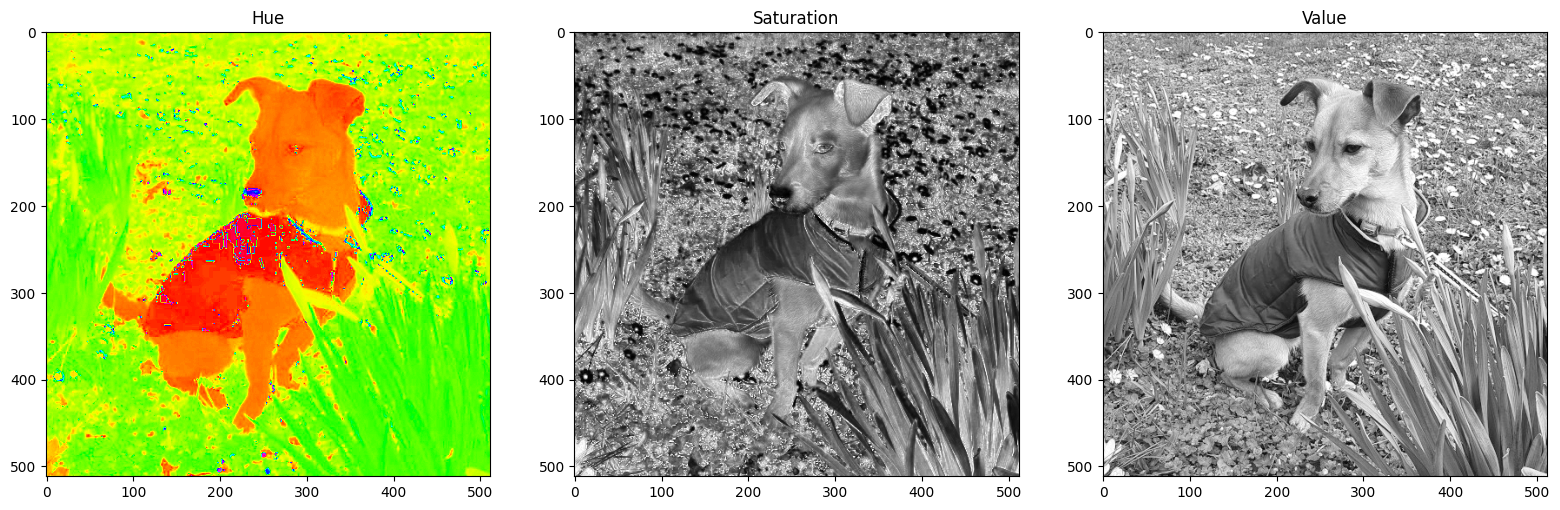

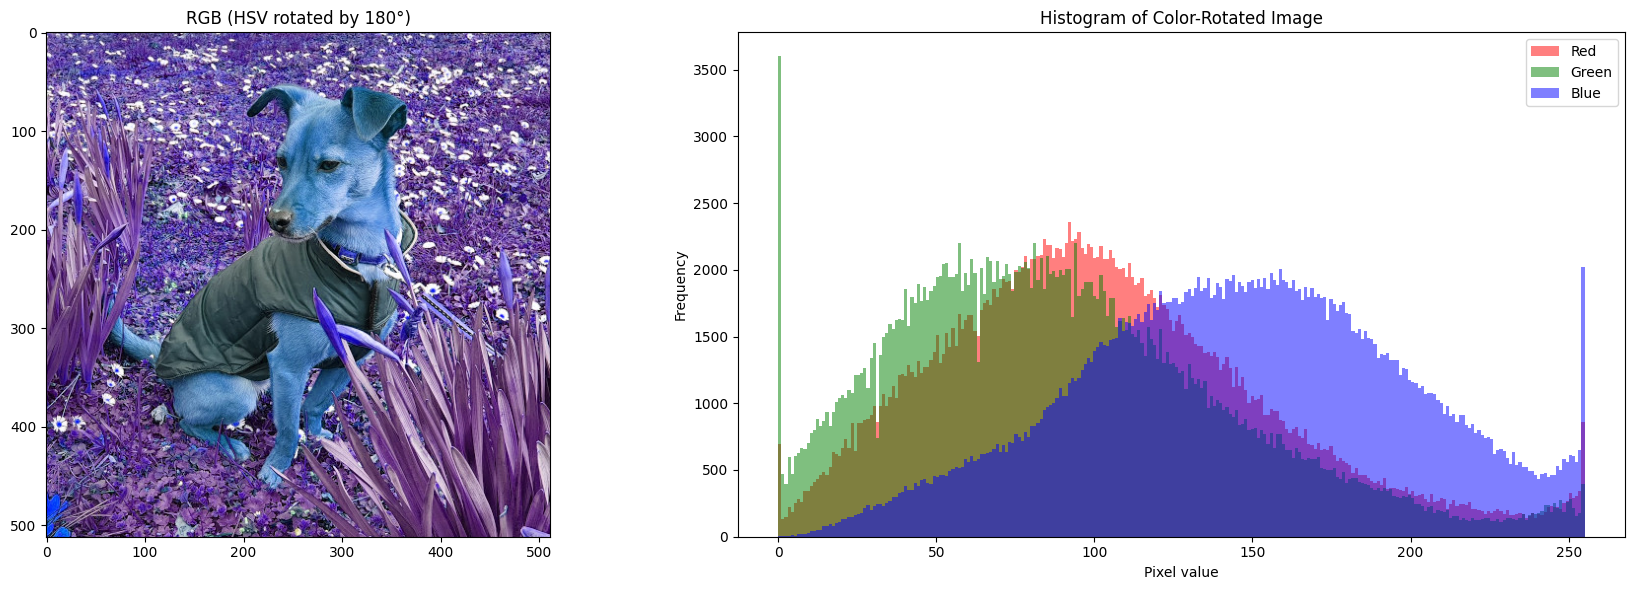

In [8]:
# Step 1: Convert RGB image to HSV color space
image_hsv = rgb2hsv(image)

# Step 2: Display the three HSV components separately
# H (Hue): Color information, displayed using HSV colormap
# S (Saturation): Color intensity, displayed in grayscale
# V (Value): Brightness, displayed in grayscale

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Display Hue channel (color information)
axs[0].imshow(image_hsv[..., 0], cmap="hsv", vmin=0.0, vmax=1.0)
axs[0].set_title("Hue")

# Display Saturation channel (color purity)
axs[1].imshow(image_hsv[..., 1], cmap="gray", vmin=0.0, vmax=1.0)
axs[1].set_title("Saturation")

# Display Value channel (brightness)
axs[2].imshow(image_hsv[..., 2], cmap="gray", vmin=0.0, vmax=1.0)
axs[2].set_title("Value")

plt.tight_layout()
plt.show()

# Step 3: Rotate the hue channel by 180 degrees (add 0.5 to normalized hue)
# This shifts all colors to their opposite side of the color wheel
image_hsv_rotated = image_hsv.copy()
image_hsv_rotated[..., 0] = (image_hsv_rotated[..., 0] + 0.5) % 1.0

# Step 4: Convert the rotated HSV image back to RGB color space
image_rgb_rotated = hsv2rgb(image_hsv_rotated)

# Step 5: Display the rotated RGB image and its color histogram
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Show the color-rotated image
axs[0].imshow(image_rgb_rotated)
axs[0].set_title("RGB (HSV rotated by 180°)")

# Extract and plot the histogram for each color channel
red = image_rgb_rotated[..., 0].ravel()
green = image_rgb_rotated[..., 1].ravel()
blue = image_rgb_rotated[..., 2].ravel()

# Plot histograms with transparency to see overlapping values
axs[1].hist(red, bins=256, range=(0, 255), color="red", alpha=0.5, label="Red")
axs[1].hist(green, bins=256, range=(0, 255), color="green", alpha=0.5, label="Green")
axs[1].hist(blue, bins=256, range=(0, 255), color="blue", alpha=0.5, label="Blue")
axs[1].set_title("Histogram of Color-Rotated Image")
axs[1].set_xlabel("Pixel value")
axs[1].set_ylabel("Frequency")
axs[1].legend()

plt.tight_layout()
plt.show()